<a href="https://colab.research.google.com/github/J1A2N3/AI_Stock_Forecasting_and_Chatbot/blob/main/AI_Stock_Forecasting_and_Chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SETUP SECTION

In [ ]:
!pip install yfinance pandas numpy matplotlib scikit-learn tensorflow gradio

IMPORT SECTION

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

import gradio as gr

DATA COLLECTION

/tmp/ipykernel_944/1944217720.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


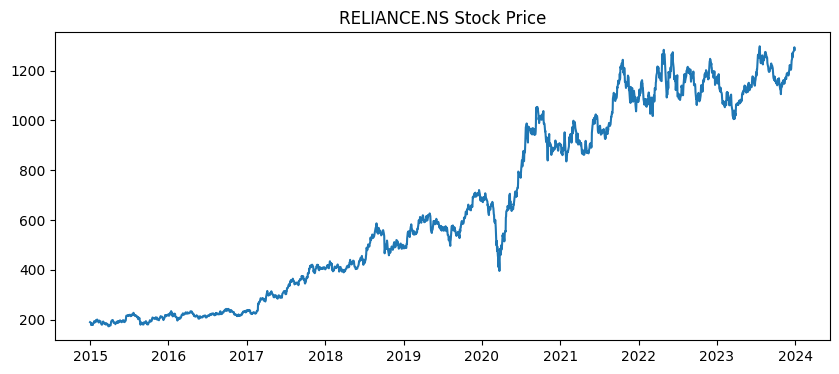

In [ ]:
ticker = "RELIANCE.NS"

data = yf.download(ticker, start="2015-01-01", end="2024-01-01")
data = data[['Close']]
data.dropna(inplace=True)

plt.figure(figsize=(10,4))
plt.plot(data)
plt.title(f"{ticker} Stock Price")
plt.show()

PREPROCESS DATA

In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data)

X = X.reshape(X.shape[0], X.shape[1], 1)

BUILD MODEL

In [ ]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(60,1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


TRAIN MODEL

In [ ]:
model.fit(X, y, epochs=5, batch_size=32)

Epoch 1/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step - loss: 0.0179
Epoch 2/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 8.1853e-04
Epoch 3/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 8.5715e-04
Epoch 4/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 7.6448e-04
Epoch 5/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 7.3014e-04


PREDICT FUTURE PRICES

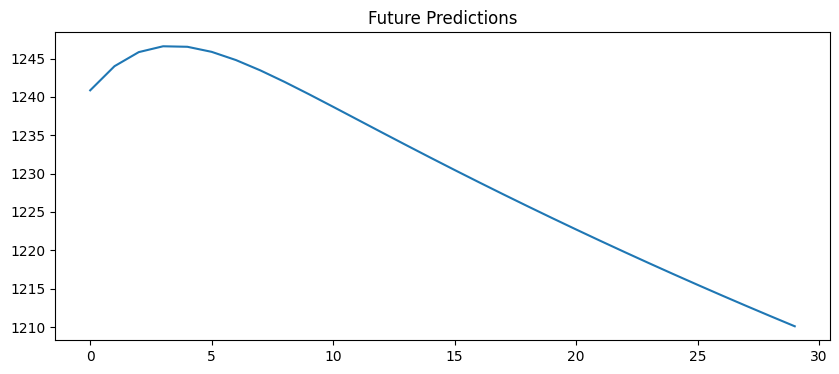

In [ ]:
def predict_future(days=30):
    temp_input = scaled_data[-60:].reshape(1, -1)
    temp_input = temp_input[0].tolist()

    output = []

    for i in range(days):
        x_input = np.array(temp_input[-60:])
        x_input = x_input.reshape(1, 60, 1)

        yhat = model.predict(x_input, verbose=0)
        temp_input.append(yhat[0][0])
        output.append(yhat[0][0])

    return scaler.inverse_transform(np.array(output).reshape(-1,1))

future_prices = predict_future(30)

plt.figure(figsize=(10,4))
plt.plot(future_prices)
plt.title("Future Predictions")
plt.show()

Q&A Logic

In [ ]:
def answer_question(question):
    question = question.lower()

    if "trend" in question:
        return "Based on past data, the model suggests a general trend (visualize the graph for clarity)."

    elif "price" in question or "future" in question:
        return f"Predicted next price: {future_prices[0][0]:.2f}"

    elif "next 5 days" in question:
        return str(future_prices[:5].flatten())

    elif "should i invest" in question:
        return "This is a demo AI model. Not financial advice."

    else:
        return "Ask about trend, future price, or predictions."

FRONTEND

In [ ]:
def chatbot(user_input):
    return answer_question(user_input)

iface = gr.Interface(
    fn=chatbot,
    inputs="text",
    outputs="text",
    title="📈 AI Stock Predictor",
    description="Ask about stock trends and predictions"
)

iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ecfed1d8556feaa814.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
